In [1]:
# RCF + cellulosic ethanol without dilute-acid pretreatment.
# Carbohydrate_Pulp from RCF feeds directly into enzymatic saccharification.

from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.ligsaf_settings import feed_parameters, prices
from lignin_saf.systems.rcf import create_rcf_system
from lignin_saf.systems.rcf_oil_purification import create_rcf_oil_purification_system
from lignin_saf.systems.monomer_purification import create_monomer_purification_system
from lignin_saf.systems.cellulosic_ethanol_no_preatreatment import create_cellulosic_ethanol_system
from lignin_saf.systems.ligsaf_utilities import create_rcf_utilities_system
from lignin_saf.cellulosic_tea import create_cellulosic_ethanol_tea

from biosteam import main_flowsheet as F
import biosteam as bst

chems = create_chemicals()
bst.settings.set_thermo(chems)
bst.settings.CEPCI = 541.7

chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price=prices['Feedstock'])

# ── Area 200: RCF process ──────────────────────────────────────────────────
rcf_system = create_rcf_system(ins=poplar_in)
rcf_system.simulate()


# ── Area 300: Purification ─────────────────────────────────────────────────
rcf_oil_purification_sys = create_rcf_oil_purification_system(ins=F.RCF_Oil)
monomer_purification_sys = create_monomer_purification_system(ins=F.Purified_RCF_Oil)
rcf_oil_purification_sys.simulate()
monomer_purification_sys.simulate()


# ── Cellulosic ethanol — Carbohydrate_Pulp feeds directly into fermentation ─
etoh_system = create_cellulosic_ethanol_system(ins=F.Carbohydrate_Pulp)
etoh_system.simulate()

# No pretreatment_wastewater — only S401 stillage filtrate goes to WWT.
etoh_ww     = [F.unit.S401.outs[1]]
etoh_solids = [F.unit.S401.outs[0]]



# ── Area 400/500: Shared utilities ─────────────────────────────────────────
BT, WWT, gas_mixer = create_rcf_utilities_system()

# Route ethanol streams into the shared RCF utilities.
F.unit.M601.ins.extend(etoh_ww)

solids_to_BT = bst.Mixer('MIX_BT_solids', ins=[WWT.outs[1]] + etoh_solids)
BT.ins[0] = solids_to_BT.outs[0]

F.unit.PWC.ins[0] = WWT.outs[2]



combined_system = bst.System(
    'Combined_Ethanol_System',
    path=(rcf_system, rcf_oil_purification_sys, monomer_purification_sys, etoh_system, WWT),
    facilities=[solids_to_BT, gas_mixer, BT],
)
combined_system.simulate()
combined_system.show()



# ── Labor (Seider methodology) ─────────────────────────────────────────────
operators_per_section = 1
num_process_sections = 3
num_operators_per_shift = operators_per_section * num_process_sections * 1
num_shifts = 5
pay_rate = 40
DWandB = num_operators_per_shift * num_shifts * 2080 * pay_rate
Dsalaries_benefits = 0.15 * DWandB
O_supplies = 0.06 * DWandB
technical_assistance = 5 * 75000
control_lab = 5 * 80000
labor = DWandB + Dsalaries_benefits + O_supplies + technical_assistance + control_lab

# ── TEA and MSP ────────────────────────────────────────────────────────────
integrated_tea = create_cellulosic_ethanol_tea(combined_system)
integrated_tea.labor_cost = labor

print(f'The MSP for RCF monomers is  {round(integrated_tea.solve_price(F.RCF_Monomers), 3)} USD/kg')


c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: Hydrogen has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\_pump.py:224: RuntimeWarning: <Pump: RCF_PUMP1> no pump type available at current power (2.34e+03 hp), head (3.2e+03 ft), kinematic viscosity (5.83e-07 m2/s), and NPSH (4.18 ft); assuming centrigugal pump
  warn(f'{repr(self)} no pump type available at current power '
c:\users\hwadg\onedrive - the pennsylvania state university\shi_wadgama_shared\models\atjspk\lignin_saf\ligsaf_units.py:411: CostWarning: <SolvolysisReactor: RCF_RXR1> Vertical vessel length (58.75 ft) is out of bounds (12 to 40 ft) for cost correlation
  self._vertical_vessel_design(
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\_unit.py:1241: CostWarning: <IsentropicCompressor: RCF_COMP1> power (1.48

System: Combined_Ethanol_System
Highest convergence error among components in recycle
streams {RCF_HX4-0, RCF_PUMP2-0} after 1 loops:
- flow rate   8.96e-11 kmol/hr (0.005%)
- temperature 7.00e-04 K (0.00022%)
ins...
[0] RCF_CAT_IN  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): NiC  2.28
[1] cellulase  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water      881
                    Cellulase  34.8
[2] saccharification_water  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water  2.69e+04
[3] stripping_water  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water  1.44e+03
[4] s59  
    phase: 'l', T: 320.15 K, P: 395168 Pa
    flow (kmol/hr): Water  0.0555
[5] air_lagoon  
    phase: 'g', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): N2  1.16e+03
                    O2  287
[6] caustic  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water  189
                    NaOH   85.3
[7] denaturant  
    phase: 'l', 

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\_unit.py:1241: CostWarning: <IsentropicCompressor: RCF_COMP1> power (0 hp) is out of bounds (10 to 750 hp) for cost correlation
  self._cost(**cost_kwargs) if cost_kwargs else self._cost()


In [6]:
import thermosteam as tmo
# Code just to increase the number of display units for the various components
tmo.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
tmo.MultiStream.display_units.N = 40  
bst.Stream.display_units.N = 40       # Increasing number of display units to see all components of streams 
bst.MultiStream.display_units.N = 40  

In [14]:
F.R301

ContinuousPresaccharification: R301
ins...
[0] s30  from  HydrolysateHeatExchanger-H301
    phase: 'l', T: 321.15 K, P: 100000 Pa
    flow (kmol/hr): Water      2.78e+04
                    Sucrose    0.243
                    Ash        1e+03
                    Lignin     68.1
                    Glucan     215
                    Xylan      78.6
                    Arabinan   0.505
                    Mannan     9.51
                    Galactan   3.6
                    Cellulase  34.8
outs...
[0] slurry  to  SaccharificationAndCoFermentation-R303
    phase: 'l', T: 319.75 K, P: 101325 Pa
    flow (kmol/hr): Water              2.75e+04
                    Furfural           3.93
                    HMF                0.683
                    Glucose            193
                    Xylose             70.7
                    Sucrose            0.243
                    Arabinose          0.454
                    Ash                1e+03
                    Lignin             68

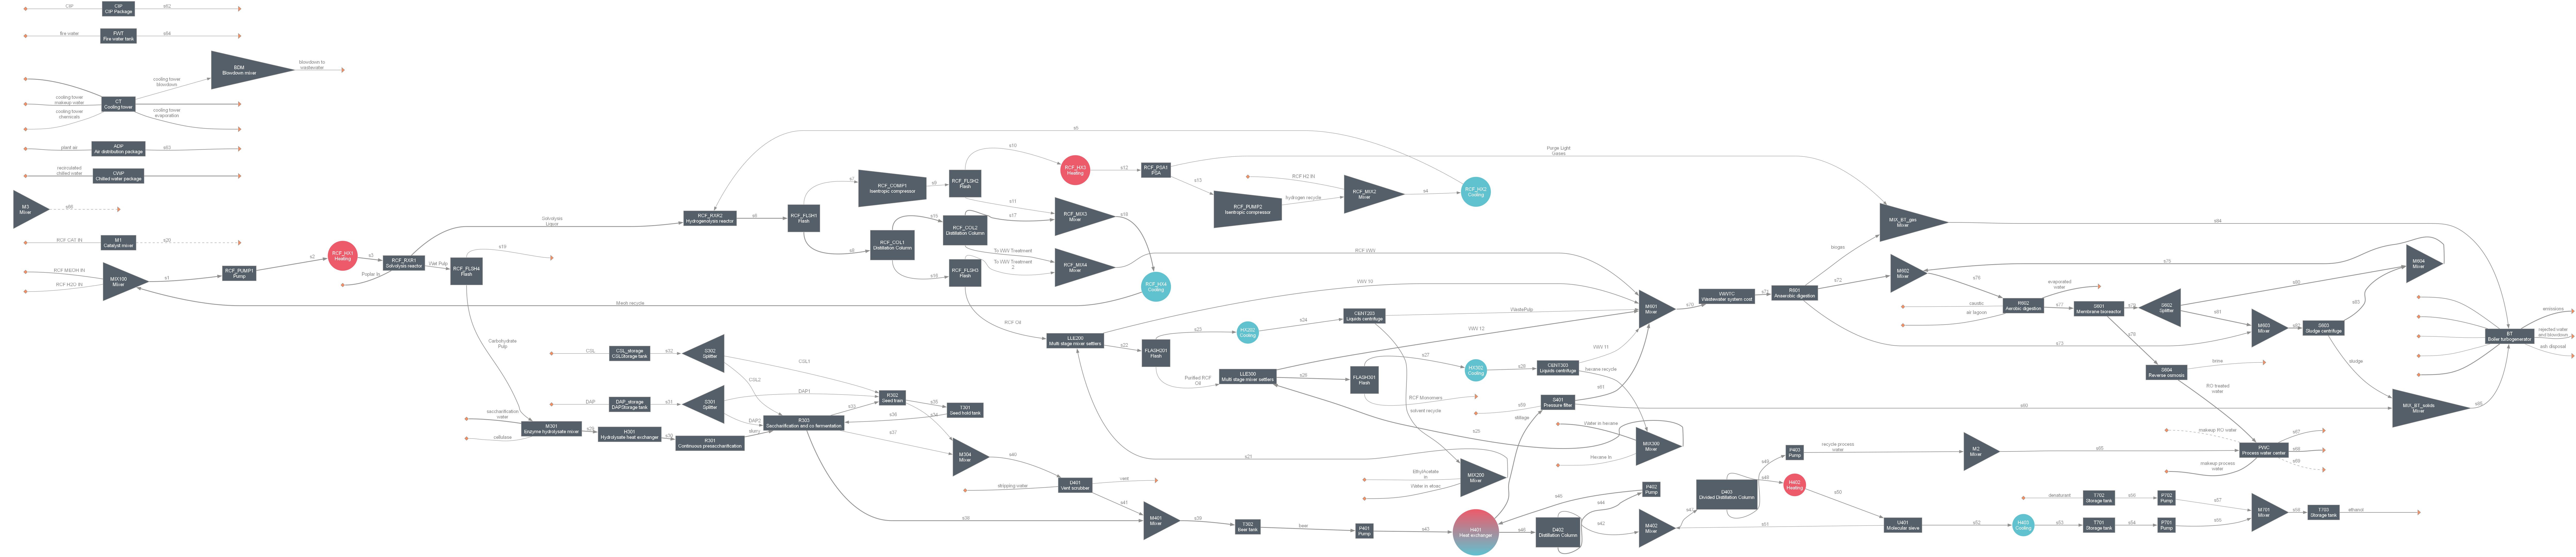

In [13]:
combined_system.diagram(format = 'png')

In [2]:
combined_system.units

[<Mixer: MIX100>,
 <Pump: RCF_PUMP1>,
 <HXutility: RCF_HX1>,
 <SolvolysisReactor: RCF_RXR1>,
 <Mixer: RCF_MIX2>,
 <HXutility: RCF_HX2>,
 <HydrogenolysisReactor: RCF_RXR2>,
 <Flash: RCF_FLSH1>,
 <IsentropicCompressor: RCF_COMP1>,
 <Flash: RCF_FLSH2>,
 <HXutility: RCF_HX3>,
 <PSA: RCF_PSA1>,
 <IsentropicCompressor: RCF_PUMP2>,
 <BinaryDistillation: RCF_COL1>,
 <BinaryDistillation: RCF_COL2>,
 <Mixer: RCF_MIX3>,
 <HXutility: RCF_HX4>,
 <Flash: RCF_FLSH3>,
 <Mixer: RCF_MIX4>,
 <Flash: RCF_FLSH4>,
 <CatalystMixer: M1>,
 <Mixer: MIX200>,
 <MultiStageMixerSettlers: LLE200>,
 <Flash: FLASH201>,
 <HXutility: HX202>,
 <LiquidsSplitCentrifuge: CENT203>,
 <Mixer: MIX300>,
 <MultiStageMixerSettlers: LLE300>,
 <Flash: FLASH301>,
 <HXutility: HX302>,
 <LiquidsSplitCentrifuge: CENT303>,
 <EnzymeHydrolysateMixer: M301>,
 <HydrolysateHeatExchanger: H301>,
 <ContinuousPresaccharification: R301>,
 <DAPStorageTank: DAP_storage>,
 <MockSplitter: S301>,
 <CSLStorageTank: CSL_storage>,
 <MockSplitter: S302>,


In [ ]:
from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.ligsaf_settings import feed_parameters, prices
from lignin_saf.systems.rcf import create_rcf_system
from lignin_saf.systems.rcf_oil_purification import create_rcf_oil_purification_system
from lignin_saf.systems.monomer_purification import create_monomer_purification_system
from lignin_saf.systems.ligsaf_utilities import create_rcf_utilities_system
from lignin_saf.systems.cellulosic_ethanol import create_cellulosic_ethanol_system
from lignin_saf.cellulosic_tea import create_cellulosic_ethanol_tea

from biosteam import main_flowsheet as F
import biosteam as bst
import pandas as pd
import numpy as np

chems = create_chemicals()
bst.settings.set_thermo(chems)
bst.settings.CEPCI = 541.7   # 2016 USD basis

# Poplar group must be defined before creating any stream that references it
chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price=prices['Feedstock'])

# ── Area 200: RCF process ──────────────────────────────────────────────────
rcf_system = create_rcf_system(ins=poplar_in)
rcf_system.simulate()

# ── Area 300: Purification ─────────────────────────────────────────────────
rcf_oil_purification_sys = create_rcf_oil_purification_system(ins=F.RCF_Oil)
monomer_purification_sys = create_monomer_purification_system(ins=F.Purified_RCF_Oil)
rcf_oil_purification_sys.simulate()
monomer_purification_sys.simulate()

# ── Cellulosic ethanol co-product ──────────────────────────────────────────
# create_cellulosic_ethanol_system omits BT (CHP) and WWT via WWT=False,
# CHP=False in its create_all_facilities call, so no ID conflicts arise
# with the shared RCF utilities created below.
ethanol_system = create_cellulosic_ethanol_system(ins=F.Carbohydrate_Pulp)
ethanol_system.simulate()

# Explicit stream routing — verified against stock cellulosic.create_cellulosic_ethanol_system:
#   fermentation vent (F.vent) is atmospheric — not burned in BT
#   CT blowdown goes to PWC via blowdown_recycle=True — not to WWT
#   cooling water and CT evaporation must not be captured
etoh_ww     = [F.pretreatment_wastewater, F.unit.S401.outs[1]]
etoh_solids = [F.unit.S401.outs[0]]

# ── Area 400/500: Shared utilities ─────────────────────────────────────────
BT, WWT, gas_mixer = create_rcf_utilities_system()

# Route ethanol streams into the shared RCF utilities.
F.unit.M601.ins.extend(etoh_ww)
solids_to_BT = bst.Mixer('MIX_BT_solids', ins=[WWT.outs[1]] + etoh_solids)
BT.ins[0] = solids_to_BT.outs[0]
# Fermentation vent is atmospheric — do NOT route to gas_mixer

# Wire WWT RO-treated water to PWC; create_all_facilities(WWT=False) leaves M2
# (placeholder mixer for WWT water) empty, so PWC would otherwise purchase
# ~480,000 kg/hr of fresh water unnecessarily (~$1.1M/yr spurious cost).
F.unit.PWC.ins[0] = WWT.outs[2]

rcf_combined_system = bst.System(
    'Combined_RCF_System',
    path=(rcf_system, rcf_oil_purification_sys, monomer_purification_sys, ethanol_system, WWT),
    facilities=[solids_to_BT, gas_mixer, BT],
)

rcf_combined_system.simulate()
rcf_combined_system.show()

# ── Labor (Seider methodology) ─────────────────────────────────────────────
operators_per_section = 1
num_process_sections = 3
num_operators_per_shift = operators_per_section * num_process_sections * 1
num_shifts = 5
pay_rate = 40
DWandB = num_operators_per_shift * num_shifts * 2080 * pay_rate
Dsalaries_benefits = 0.15 * DWandB
O_supplies = 0.06 * DWandB
technical_assistance = 5 * 75000
control_lab = 5 * 80000
labor = DWandB + Dsalaries_benefits + O_supplies + technical_assistance + control_lab

# ── TEA and MSP ────────────────────────────────────────────────────────────
integrated_tea = create_cellulosic_ethanol_tea(rcf_combined_system)
integrated_tea.labor_cost = labor

print(f'The MSP for RCF monomers is  {round(integrated_tea.solve_price(F.RCF_Monomers), 3)} USD/kg')


c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\equilibrium\bubble_point.py:128: RuntimeWarning: Hydrogen has no defined Dortmund groups; functional group interactions are ignored
  self.gamma = thermo.Gamma(chemicals)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\units\_pump.py:224: RuntimeWarning: <Pump: RCF_PUMP1> no pump type available at current power (2.34e+03 hp), head (3.2e+03 ft), kinematic viscosity (5.83e-07 m2/s), and NPSH (4.18 ft); assuming centrigugal pump
  warn(f'{repr(self)} no pump type available at current power '
c:\users\hwadg\onedrive - the pennsylvania state university\shi_wadgama_shared\models\atjspk\lignin_saf\ligsaf_units.py:411: CostWarning: <SolvolysisReactor: RCF_RXR1> Vertical vessel length (58.75 ft) is out of bounds (12 to 40 ft) for cost correlation
  self._vertical_vessel_design(
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\_unit.py:1241: CostWarning: <IsentropicCompressor: RCF_COMP1> power (1.48

System: Combined_RCF_System
Highest convergence error among components in recycle
streams {RCF_HX4-0, RCF_PUMP2-0} after 1 loops:
- flow rate   8.96e-11 kmol/hr (0.005%)
- temperature 7.00e-04 K (0.00022%)
ins...
[0] RCF_CAT_IN  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): NiC  2.28
[1] warm_process_water_1  
    phase: 'l', T: 368.15 K, P: 476228 Pa
    flow (kmol/hr): Water  921
[2] pretreatment_steam  
    phase: 'g', T: 541.15 K, P: 1.31722e+06 Pa
    flow (kmol/hr): Water  959
[3] warm_process_water_2  
    phase: 'l', T: 368.15 K, P: 476228 Pa
    flow (kmol/hr): Water  6.86e+03
[4] ammonia_process_water  
    phase: 'l', T: 368.15 K, P: 476228 Pa
    flow (kmol/hr): Water  3.5e+03
[5] sulfuric_acid  
    phase: 'l', T: 294.15 K, P: 547155 Pa
    flow (kmol/hr): Water  5.09
                    H2SO4  13
[6] cellulase  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow (kmol/hr): Water      788
                    Cellulase  31.1
[7] saccharification_water  
   

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\biosteam\_unit.py:1241: CostWarning: <IsentropicCompressor: RCF_COMP1> power (0 hp) is out of bounds (10 to 750 hp) for cost correlation
  self._cost(**cost_kwargs) if cost_kwargs else self._cost()


In [ ]:
rcf_combined_system.installed_cost/1e6

528.2077918183609